In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

def remove_outliers(df):
    df = df.copy()
    df = df.drop_duplicates()
    df = df[df["density"] <= 1.01]
    df = df[df["chlorides"] < 0.3]
    df = df[df["fixed acidity"] < 12]
    df = df[df["free sulfur dioxide"] < 100]
    df = df[df["citric acid"] < 0.75]
    df = df[df["total sulfur dioxide"] < 300]
    df = df[df["sulphates"] < 1.25]
    return df

def feature_engineering(df):
    df = df.copy()
    df["type"] = df["type"].map({"red": 0, "white": 1})
    df["quality"] = pd.cut(
        df["quality"],
        bins=[0, 4, 6, 10],
        labels=["Low", "Intermediate", "High"]
    )
    df["quality"] = df["quality"].map({"Low": 0, "Intermediate": 1, "High": 2})
    return df

def split(dataframe, random_state=42, train_size=0.8):
    dataframe = feature_engineering(dataframe)
    X = dataframe.drop(columns=["quality"])
    y = dataframe["quality"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=(1 - train_size),
        stratify=y,
        random_state=random_state
    )

    train_df = X_train.assign(quality=y_train)
    train_df = remove_outliers(train_df)
    X_train = train_df.drop(columns=["quality"])
    y_train = train_df["quality"]

    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
    X_test  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns)
    return X_train, X_test, y_train, y_test, scaler

def apply_smote(
    X_train,
    y_train,
    sampling_strategy="auto",
    k_neighbors=5,
    random_state=42
):
    """
    Aplica SMOTE no conjunto de treino para balanceamento de classes.

    Parameters
    ----------
    X_train : array-like or pd.DataFrame
        Features do conjunto de treino.
    y_train : array-like or pd.Series
        Labels do conjunto de treino.
    sampling_strategy : str, dict or float, default="auto"
        Estratégia de balanceamento.
        - "auto": balanceia todas as classes minoritárias até a majoritária
        - dict: define número desejado por classe, ex: {0: 200, 2: 300}
    k_neighbors : int, default=5
        Número de vizinhos usados na interpolação.
        Use valores menores (ex: 3) para classes muito pequenas.
    random_state : int, default=42
        Reprodutibilidade.

    Returns
    -------
    X_resampled : array-like
        Features após SMOTE.
    y_resampled : array-like
        Labels após SMOTE.
    """

    smote = SMOTE(
        sampling_strategy=sampling_strategy,
        k_neighbors=k_neighbors,
        random_state=random_state
    )

    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    return X_resampled, y_resampled

In [3]:
df = pd.read_csv("../dataset/wine_quality_red_white.csv")
X_train, X_test, y_train, y_test, scaler = split(df)
X_train, y_train = apply_smote(X_train, y_train)

In [4]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from scipy.stats import randint, uniform


def train_XGBoost(X_train, y_train):
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    param_dist = {
        'n_estimators': randint(200, 1000),
        'learning_rate': [0.005, 0.01, 0.05, 0.1, 0.2],
        'max_depth': randint(3, 15),
        'min_child_weight': randint(1, 15),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'gamma': uniform(0, 0.5),
        'reg_alpha': uniform(0, 1),
        'reg_lambda': uniform(0.5, 2),
    }

    xgb_clf = XGBClassifier(
        random_state=42,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss'
    )

    random_search = RandomizedSearchCV(
        estimator=xgb_clf,
        param_distributions=param_dist,
        n_iter=200,
        cv=5,
        scoring='f1_weighted',
        refit=True,
        return_train_score=True,
        random_state=42,
        n_jobs=-1
    )

    print("Starting hyperparameter search...")
    random_search.fit(X_train, y_train, sample_weight=sample_weights)
    print("Finished!")

    print(f"Best CV F1: {random_search.best_score_:.4f}")
    print(f"Best params: {random_search.best_params_}")

    return random_search.best_estimator_, random_search.best_params_



In [77]:
estimator, params = train_XGBoost(X_train, y_train)

Starting hyperparameter search...
Finished!
Best CV F1: 0.9172
Best params: {'colsample_bytree': np.float64(0.7537338668804181), 'gamma': np.float64(0.00319293585841679), 'learning_rate': 0.2, 'max_depth': 13, 'min_child_weight': 1, 'n_estimators': 432, 'reg_alpha': np.float64(0.6318135270166684), 'reg_lambda': np.float64(1.0196071621283196), 'subsample': np.float64(0.8170028515498057)}


In [5]:
import joblib

artifacts = joblib.load("dummy_models/model_XGBoost.joblib")

model = artifacts["model"]
scaler = artifacts["scaler"]

In [8]:
y_pred = model.predict(X_test)

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test F1: {f1:.4f}")

Test F1: 0.8358


In [10]:
import numpy as np
thresholds = np.linspace(0.1, 0.9, 100)
f1_scores = []
def predict_with_thresholds(y_proba, thresholds):
    # y_proba: (n_samples, n_classes)
    # thresholds: array shape (n_classes,)
    scores = y_proba / thresholds
    return np.argmax(scores, axis=1)

from sklearn.metrics import f1_score

def optimize_thresholds(y_proba, y_true):
    grid = np.linspace(0.2, 0.8, 7)  # coarse grid

    best_f1 = -1
    best_t = None

    for t0 in grid:
        for t1 in grid:
            for t2 in grid:
                thresholds = np.array([t0, t1, t2])
                y_pred = predict_with_thresholds(y_proba, thresholds)

                f1 = f1_score(y_true, y_pred, average='weighted')

                if f1 > best_f1:
                    best_f1 = f1
                    best_t = thresholds

    return best_t, best_f1

In [11]:
y_proba = model.predict_proba(X_test)
y_true = y_test.values

best_thresholds, best_f1 = optimize_thresholds(y_proba, y_true)

print("Best thresholds:", best_thresholds)
print("Best F1:", best_f1)

Best thresholds: [0.2 0.2 0.5]
Best F1: 0.8440946395243084


<Figure size 1200x500 with 0 Axes>

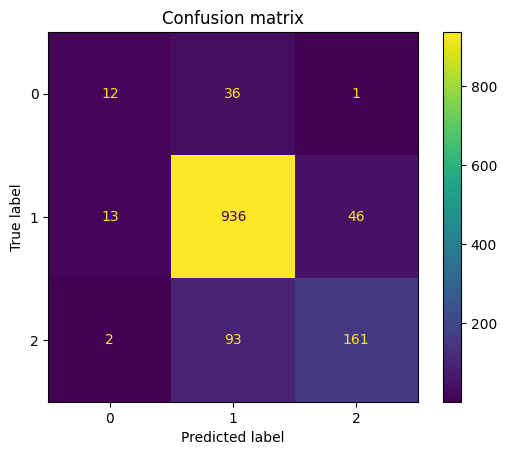

In [13]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred_opt = predict_with_thresholds(y_proba, best_thresholds)

fig = plt.figure(figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_opt
)
plt.title("Confusion matrix")

plt.show()

In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_opt))

              precision    recall  f1-score   support

           0       0.44      0.24      0.32        49
           1       0.88      0.94      0.91       995
           2       0.77      0.63      0.69       256

    accuracy                           0.85      1300
   macro avg       0.70      0.60      0.64      1300
weighted avg       0.84      0.85      0.84      1300



# Random Forest Classification

In [12]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint


def train_RandomForest(X_train, y_train):
    sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

    param_dist = {
        'n_estimators': randint(200, 1000),
        'max_depth': randint(3, 20),
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 20),
        'max_features': ['sqrt', 'log2', None],
        'bootstrap': [True, False]
    }

    rf_clf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    )

    random_search = RandomizedSearchCV(
        estimator=rf_clf,
        param_distributions=param_dist,
        n_iter=200,
        cv=5,
        scoring='f1_weighted',
        refit=True,
        return_train_score=True,
        random_state=42,
        n_jobs=-1
    )

    print("Starting Random Forest hyperparameter search...")
    random_search.fit(X_train, y_train, sample_weight=sample_weights)
    print("Finished!")

    print(f"Best CV F1: {random_search.best_score_:.4f}")
    print(f"Best params: {random_search.best_params_}")

    return random_search.best_estimator_, random_search.best_params_

In [79]:
rf_estimator, rf_params = train_RandomForest(X_train, y_train)

Starting Random Forest hyperparameter search...


/media/leonardo-stabile/HD1TB/PROJETOS/Wine Quality/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/media/leonardo-stabile/HD1TB/PROJETOS/Wine Quality/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/media/leonardo-stabile/HD1TB/PROJETOS/Wine Quality/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/media/leonardo-s

Finished!
Best CV F1: 0.9119
Best params: {'bootstrap': False, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 345}


In [82]:
y_pred = rf_estimator.predict(X_test)

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Test F1: {f1:.4f}")

Test F1: 0.8241


In [ ]:
import joblib

def save_artifacts(path, model, scaler=None):
    artifacts = {
        "model": model,
        "scaler": scaler,
    }
    joblib.dump(artifacts, path)

In [83]:
save_artifacts(
    "dummy_models/model_XGBoost.joblib",
    model=estimator,
    scaler=scaler
)

save_artifacts(
    "dummy_models/model_RF.joblib",
    model=rf_estimator,
    scaler=scaler
)

In [15]:
artifacts_rf = joblib.load("dummy_models/model_RF.joblib")

rf_model = artifacts_rf["model"]
scaler_rf = artifacts_rf["scaler"]

In [16]:
y_proba = rf_model.predict_proba(X_test)
y_true = y_test.values

best_thresholds, best_f1 = optimize_thresholds(y_proba, y_true)

print("Best thresholds:", best_thresholds)
print("Best F1:", best_f1)

Best thresholds: [0.3 0.3 0.7]
Best F1: 0.8426254069060191


<Figure size 1200x500 with 0 Axes>

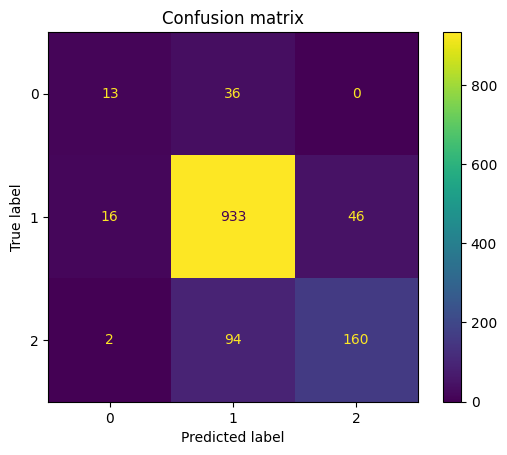

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred_opt = predict_with_thresholds(y_proba, best_thresholds)

fig = plt.figure(figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_opt
)
plt.title("Confusion matrix")

plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_opt))

              precision    recall  f1-score   support

           0       0.42      0.27      0.33        49
           1       0.88      0.94      0.91       995
           2       0.78      0.62      0.69       256

    accuracy                           0.85      1300
   macro avg       0.69      0.61      0.64      1300
weighted avg       0.84      0.85      0.84      1300

